# Example-06: Synchronization check & phase correction

In [1]:
# Import

import numpy
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# In this example synchonization error (wrong starting turn) and corresponding phase correction is presented
# Separate function is available in Twiss class

In [4]:
# Load phase advance data

with open('../config.yaml', 'r') as stream:
    config = yaml.safe_load(stream)
    config = {key: config[key] for key in sorted(config.keys(), key=lambda name: config[name]['TIME'])}
advance = numpy.array([value['FX'] for key, value in config.items() if value['TYPE'] == 'MONITOR' or key == 'TAIL'])
advance = numpy.diff(advance)
advance = torch.tensor(advance, dtype=dtype, device=device)

In [5]:
# Set window

length = 1024
w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)

# Load data

table = numpy.load('../virtual_tbt.npy')

# Set correct starting position for all signals

start = 128

# Set synchronization errors
# If shifted in + by one, need to - for correction
# If shifted in - by one, need to + for correction

error = {10: 127, 31: 129, 32:129, 41:127, 43:129}

# Set data

d = torch.zeros((54, length), dtype=dtype, device=device)
for i in range(54):
    first = start if i not in error else error[i]
    d[i] = torch.tensor(table[i, first: first + length])
d = Data.from_data(w, d)

# Add random noise

n = 1.0E-6*(25.0 + 75.0*torch.rand(54, dtype=dtype, device=device))
d.add_noise(n)
d.data.copy_(d.work)

# Estimate frequency (average over signals)

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
frequency, spread = f.frequency.mean(), f.frequency.std()
frequency = 1.0 - frequency
print(f'frequency={frequency.item():12.9}, spread={spread.item():12.9}')

frequency= 0.536883116, spread=1.42096061e-06


8.536883116127028
12.536883116127026


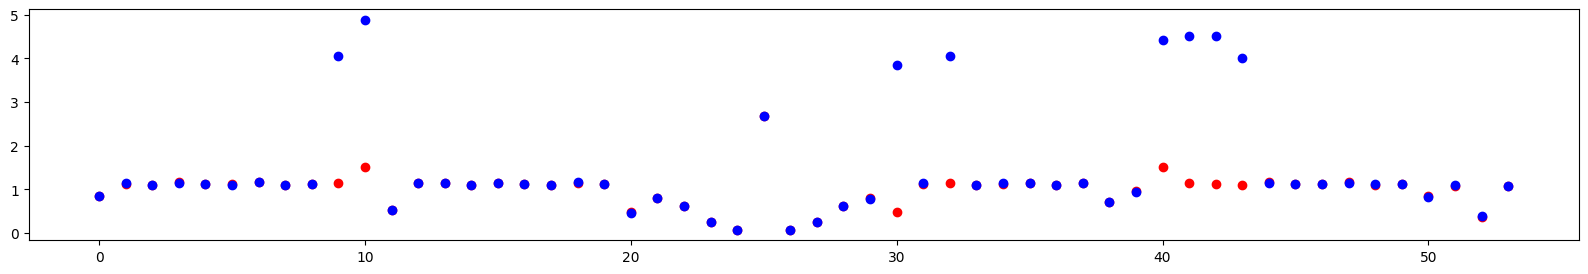

In [6]:
# Estimate phase and compute phase advance

dec = Decomposition(d)
out, _, _ = dec.harmonic_phase(frequency, length=512, order=0.0)
add, _ = Decomposition.phase_adjacent(frequency, out)

# Total advance might be used as indicator in some cases (not robust)

print((8.0 + frequency).item())
print((add.sum()/(2.0*numpy.pi)).item())

# Plot phase advance

plt.figure(figsize=(20, 3))
plt.scatter(range(54), advance.cpu().numpy(), color='red')
plt.scatter(range(54), add.cpu().numpy(), color='blue')
plt.show()

In [7]:
# To perform a more robust test & correction, the following is assumed:

# A) most of signals have no synchronization error
# B) signal can be off only by one turn in any direction
# C) without synchronization errors phase advance is close to model (some threshold can be specified)

# With these assumptions, it is possible to identify signals that might have a synchronization error
# To do this, pairs with large advance error are marked (based on robust dispersion or other methods, see below)
# Other pairs are assumed to be correct
# Signals at the endpoints are correct
# Select adjacent signal with correct phase and right marked signal, check the effect of adding or subtracting of one turn
# If such correction results in significant improvement, change corresponding phase (starting position might not be avalible)
# Do this for all marked signals

# If synchronization error is indeed present, results should match for both planes

# Ones corrected, tests can be performed again (e.g. when not all pairs are marked initialy)

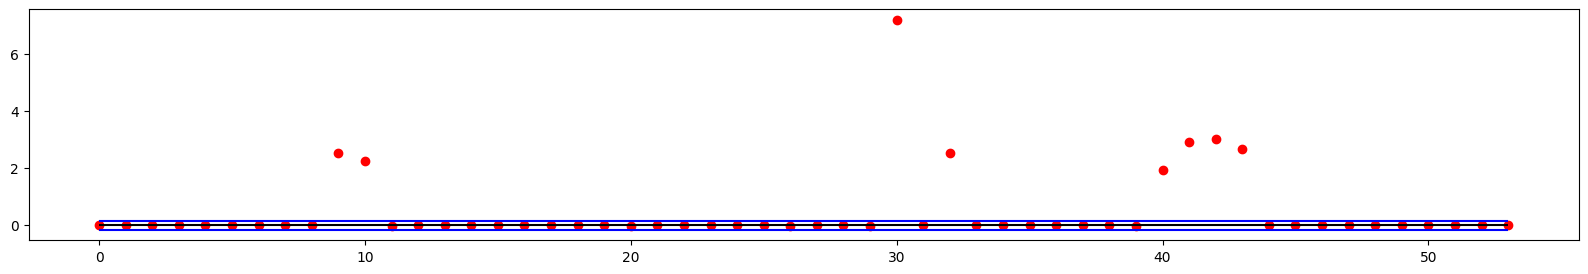

In [8]:
# Plot difference from the model model

delta = (add-advance)/advance

q25 = torch.quantile(delta, 0.25).cpu().numpy()
q50 = torch.quantile(delta, 0.50).cpu().numpy()
q75 = torch.quantile(delta, 0.75).cpu().numpy()

l, u = q25 - 10.0*(q75 - q25), q75 + 10.0*(q75 - q25)

plt.figure(figsize=(20, 3))
plt.scatter(range(54), delta.cpu().numpy(), color='red')
plt.hlines(q50, 0, 53, colors='black')
plt.hlines(l, 0, 53, colors='blue')
plt.hlines(u, 0, 53, colors='blue')
plt.show()

In [9]:
# LOF

from sklearn.neighbors import LocalOutlierFactor
detector = LocalOutlierFactor(contamination=0.05)
pairs = detector.fit_predict(delta.reshape(-1, 1).cpu().numpy())
pairs, *_ = numpy.in1d(delta.cpu().numpy(), delta[pairs == -1].cpu().numpy()).nonzero()
pairs = [[i, i + 1] for i in tuple(pairs)]
print(pairs)

[[30, 31], [41, 42], [42, 43]]


In [10]:
# IFO

from sklearn.ensemble import IsolationForest
detector = IsolationForest(contamination=0.05)
pairs = detector.fit_predict(delta.reshape(-1, 1).cpu().numpy())
pairs, *_ = numpy.in1d(delta.cpu().numpy(), delta[pairs == -1].cpu().numpy()).nonzero()
pairs = [[i, i + 1] for i in tuple(pairs)]
print(pairs)

[[30, 31], [40, 41], [42, 43]]


In [11]:
# DBSCAN

from sklearn.cluster import DBSCAN
from collections import Counter
cluster = DBSCAN().fit(delta.reshape(-1, 1).cpu().numpy())
label, *_ = Counter(cluster.labels_)
pairs, *_ = numpy.in1d(delta.cpu().numpy(), delta[cluster.labels_ != label].cpu().numpy()).nonzero()
pairs = [[i, i + 1] for i in tuple(pairs)]
print(pairs)

[[9, 10], [10, 11], [30, 31], [32, 33], [40, 41], [41, 42], [42, 43], [43, 44]]


In [12]:
# Pairs outside acceptance region

l_p, *_ = numpy.where(delta.cpu().numpy() < l)
u_p, *_ = numpy.where(delta.cpu().numpy() > u)
marked = (*tuple(l_p), *tuple(u_p))
marked = [[i, i + 1] for i in marked]
print(marked)

[[9, 10], [10, 11], [30, 31], [32, 33], [40, 41], [41, 42], [42, 43], [43, 44]]


In [13]:
# Marked signals

table = []
chain = []
for i in numpy.unique(numpy.array(pairs).flatten()):
    if chain == []:
        chain.append(i)
        value = i
        continue
    if i == value + 1:
        chain.append(i)
        value = i
        continue
    table.append(chain)
    chain = []
    chain.append(i)
    value = i
else:
    table.append(chain)
print(table)
    
# Remove endpoints

table = [*map(lambda x: x[1:-1], table)]
print(table)

# Set marked and passed

marked = [j for i in table for j in i]
passed = [i for i in range(54) if i not in marked]

# Set phase

phase = torch.clone(out)

# Correct

for i in marked:
    phase_x = phase[i-1]
    phase_y = phase[i]
    phase_y = phase_y + torch.stack([-2.0*numpy.pi*frequency, 0.0*numpy.pi*frequency, +2.0*numpy.pi*frequency])
    phase_y = mod(phase_y, 2*numpy.pi, -numpy.pi)
    delta = mod(phase_y - phase_x, 2*numpy.pi)
    delta = torch.abs(delta - advance[i-1])
    index = delta.argmin().item()
    print(f"{i}: {['+', ' ', '-'][index]}, {128 + [+1, 0, -1][index]}")
    phase[i] = phase_y[index]
    
print(error)

[[9, 10, 11], [30, 31, 32, 33], [40, 41, 42, 43, 44]]
[[10], [31, 32], [41, 42, 43]]
10: -, 127
31: +, 129
32: +, 129
41: -, 127
42:  , 128
43: +, 129
{10: 127, 31: 129, 32: 129, 41: 127, 43: 129}


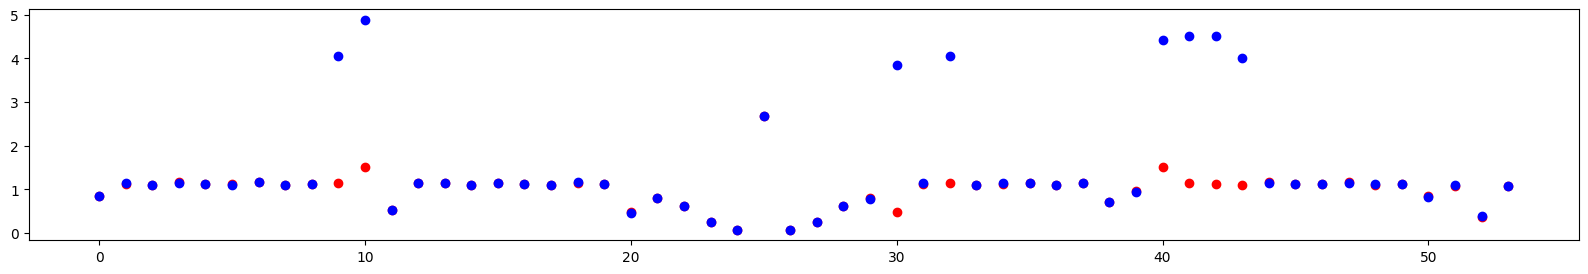

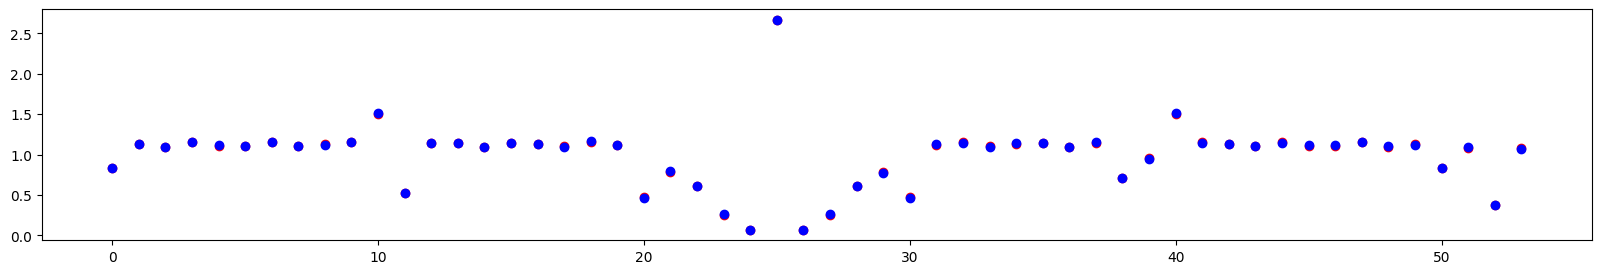

In [14]:
# Plot advance using corrected phase

plt.figure(figsize=(20, 3))
plt.scatter(range(54), advance.cpu().numpy(), color='red')
plt.scatter(range(54), add.cpu().numpy(), color='blue')
plt.show()

correct, _ = Decomposition.phase_adjacent(frequency, phase)
plt.figure(figsize=(20, 3))
plt.scatter(range(54), advance.cpu().numpy(), color='red')
plt.scatter(range(54), correct.cpu().numpy(), color='blue')
plt.show()

{10: 127, 31: 129, 32: 129, 41: 127, 43: 129}
{10: 127, 31: 129, 32: 129, 41: 127, 43: 129}


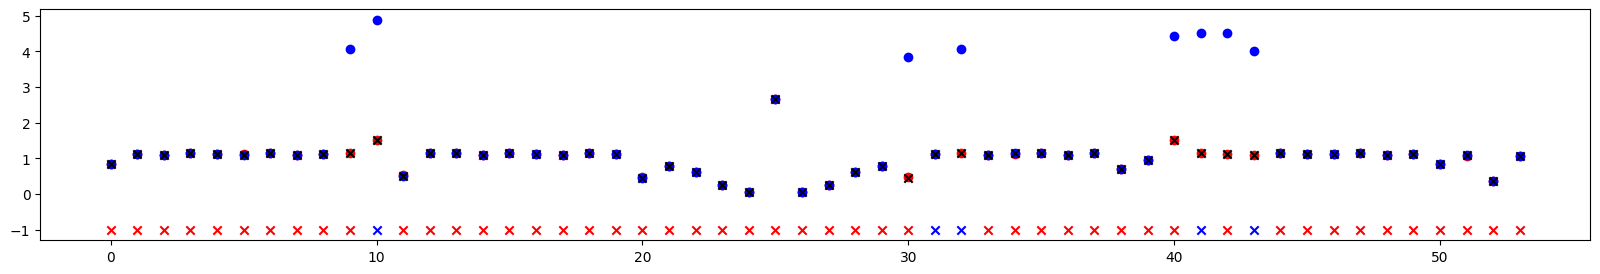

In [15]:
# phase_check classmethod can be used to perform shyncronization test
# robust spread is used to flag outliers

print(error)

q = frequency.item()
phase = out

Q = config['TAIL']['FX']/(2.0*numpy.pi)
PHASE = torch.tensor([value['FX'] for key, value in config.items() if value['TYPE'] == 'MONITOR'], dtype=dtype, device=device)

result, select = Decomposition.phase_check(q, Q, phase, PHASE)
result = {key: value[0] + start for key, value in result.items() if value[0] != 0}
print(result)

plt.figure(figsize=(20, 3))
plt.scatter(range(54), select['model'].cpu().numpy(), color='red')
plt.scatter(range(54), select['phase'].cpu().numpy(), color='blue')
plt.scatter(range(54), select['check'].cpu().numpy(), color='black', marker='x')
plt.scatter(*numpy.array([[index, -1.0] for index in range(54) if index not in result]).T, color='red', marker='x')
plt.scatter(*numpy.array([[index, -1.0] for index in range(54) if index in result]).T, color='blue', marker='x')
plt.show()